<a href="https://www.kaggle.com/code/robiulhasanjisan/pharma-risk-classifier?scriptVersionId=311771194" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mdmahfuzsumon/pharma-dataset-drug-classes-interactions-and-cli-pr/pharma_realistic_10000.csv


In [4]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings('ignore')


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, callbacks
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False
    print("TensorFlow not available. Skipping deep learning models.")

# For SHAP analysis
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available. Install with: pip install shap")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)


available_styles = plt.style.available

if 'seaborn-v0_8-darkgrid' in available_styles:
    plt.style.use('seaborn-v0_8-darkgrid')
elif 'seaborn-darkgrid' in available_styles:
    plt.style.use('seaborn-darkgrid')
else:
    plt.style.use('ggplot')


sns.set_theme(style="darkgrid", palette="husl")

# Global plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


2026-04-15 11:13:10.895647: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776251590.922094     161 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776251590.929715     161 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776251590.950232     161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776251590.950266     161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776251590.950269     161 computation_placer.cc:177] computation placer alr

#  LOAD DATA

In [5]:

df = pd.read_csv('/kaggle/input/datasets/mdmahfuzsumon/pharma-dataset-drug-classes-interactions-and-cli-pr/pharma_realistic_10000.csv')


In [6]:
print(f" Dataset Shape: {df.shape}")

 Dataset Shape: (10000, 20)


In [7]:
print(f"\n Columns: {df.columns.tolist()}")


 Columns: ['id', 'active_ingredient', 'brand_name', 'manufacturer', 'therapeutic_group', 'pharmacological_class', 'drug_type', 'strength', 'dosage_form', 'route', 'indication', 'indication_category', 'side_effects', 'pregnancy_category', 'controlled_substance', 'otc_or_rx', 'food_interaction', 'alcohol_interaction', 'num_ingredients', 'is_combination_drug']


In [8]:
print(df.head())

   id          active_ingredient brand_name manufacturer therapeutic_group  \
0   1  Amoxicillin + Clavulanate  Augmentin          GSK        Antibiotic   
1   2                 Omeprazole      Seclo  AstraZeneca           Antacid   
2   3               Azithromycin       Azit      Incepta        Antibiotic   
3   4                 Salbutamol     Brodil          GSK    Bronchodilator   
4   5                 Lisinopril    Listril  AstraZeneca  Antihypertensive   

                    pharmacological_class       drug_type strength  \
0  Beta-lactam + Beta-lactamase inhibitor  Small molecule  1000 mg   
1                   Proton pump inhibitor  Small molecule    10 mg   
2                               Macrolide  Small molecule   250 mg   
3                          Beta-2 agonist  Small molecule     2 mg   
4                           ACE inhibitor  Small molecule    10 mg   

  dosage_form route             indication indication_category  \
0       Syrup  Oral              Infection  

In [9]:
print(f"\n Missing Values:\n{df.isnull().sum()}")


 Missing Values:
id                       0
active_ingredient        0
brand_name               0
manufacturer             0
therapeutic_group        0
pharmacological_class    0
drug_type                0
strength                 0
dosage_form              0
route                    0
indication               0
indication_category      0
side_effects             0
pregnancy_category       0
controlled_substance     0
otc_or_rx                0
food_interaction         0
alcohol_interaction      0
num_ingredients          0
is_combination_drug      0
dtype: int64


In [10]:
print(f"\n Data Types:\n{df.dtypes}")


 Data Types:
id                        int64
active_ingredient        object
brand_name               object
manufacturer             object
therapeutic_group        object
pharmacological_class    object
drug_type                object
strength                 object
dosage_form              object
route                    object
indication               object
indication_category      object
side_effects             object
pregnancy_category       object
controlled_substance     object
otc_or_rx                object
food_interaction          int64
alcohol_interaction       int64
num_ingredients           int64
is_combination_drug       int64
dtype: object


In [11]:
print(df.describe())

                id  food_interaction  alcohol_interaction  num_ingredients  \
count  10000.00000       10000.00000         10000.000000     10000.000000   
mean    5000.50000           0.47200             0.665900         1.065600   
std     2886.89568           0.49924             0.471698         0.247594   
min        1.00000           0.00000             0.000000         1.000000   
25%     2500.75000           0.00000             0.000000         1.000000   
50%     5000.50000           0.00000             1.000000         1.000000   
75%     7500.25000           1.00000             1.000000         1.000000   
max    10000.00000           1.00000             1.000000         2.000000   

       is_combination_drug  
count         10000.000000  
mean              0.065600  
std               0.247594  
min               0.000000  
25%               0.000000  
50%               0.000000  
75%               0.000000  
max               1.000000  


In [12]:

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head())


active_ingredient: 15 unique values
active_ingredient
Ciprofloxacin    725
Cetirizine       705
Metformin        695
Omeprazole       687
Lisinopril       683
Name: count, dtype: int64

brand_name: 61 unique values
brand_name
Lisinace    191
Flocin      189
Ciprosin    187
Zyrtec      185
Listril     183
Name: count, dtype: int64

manufacturer: 15 unique values
manufacturer
Square     2245
Incepta    1655
Beximco    1402
Renata     1277
ACI        1082
Name: count, dtype: int64

therapeutic_group: 9 unique values
therapeutic_group
Antibiotic          2034
Antihypertensive    2005
Antidiabetic        1362
Analgesic           1327
Antihistamine        705
Name: count, dtype: int64

pharmacological_class: 15 unique values
pharmacological_class
Fluoroquinolone          725
H1 antagonist            705
Biguanide                695
Proton pump inhibitor    687
ACE inhibitor            683
Name: count, dtype: int64

drug_type: 2 unique values
drug_type
Small molecule    9333
Biologic        

# EDA

## Categorical Distribution Plots

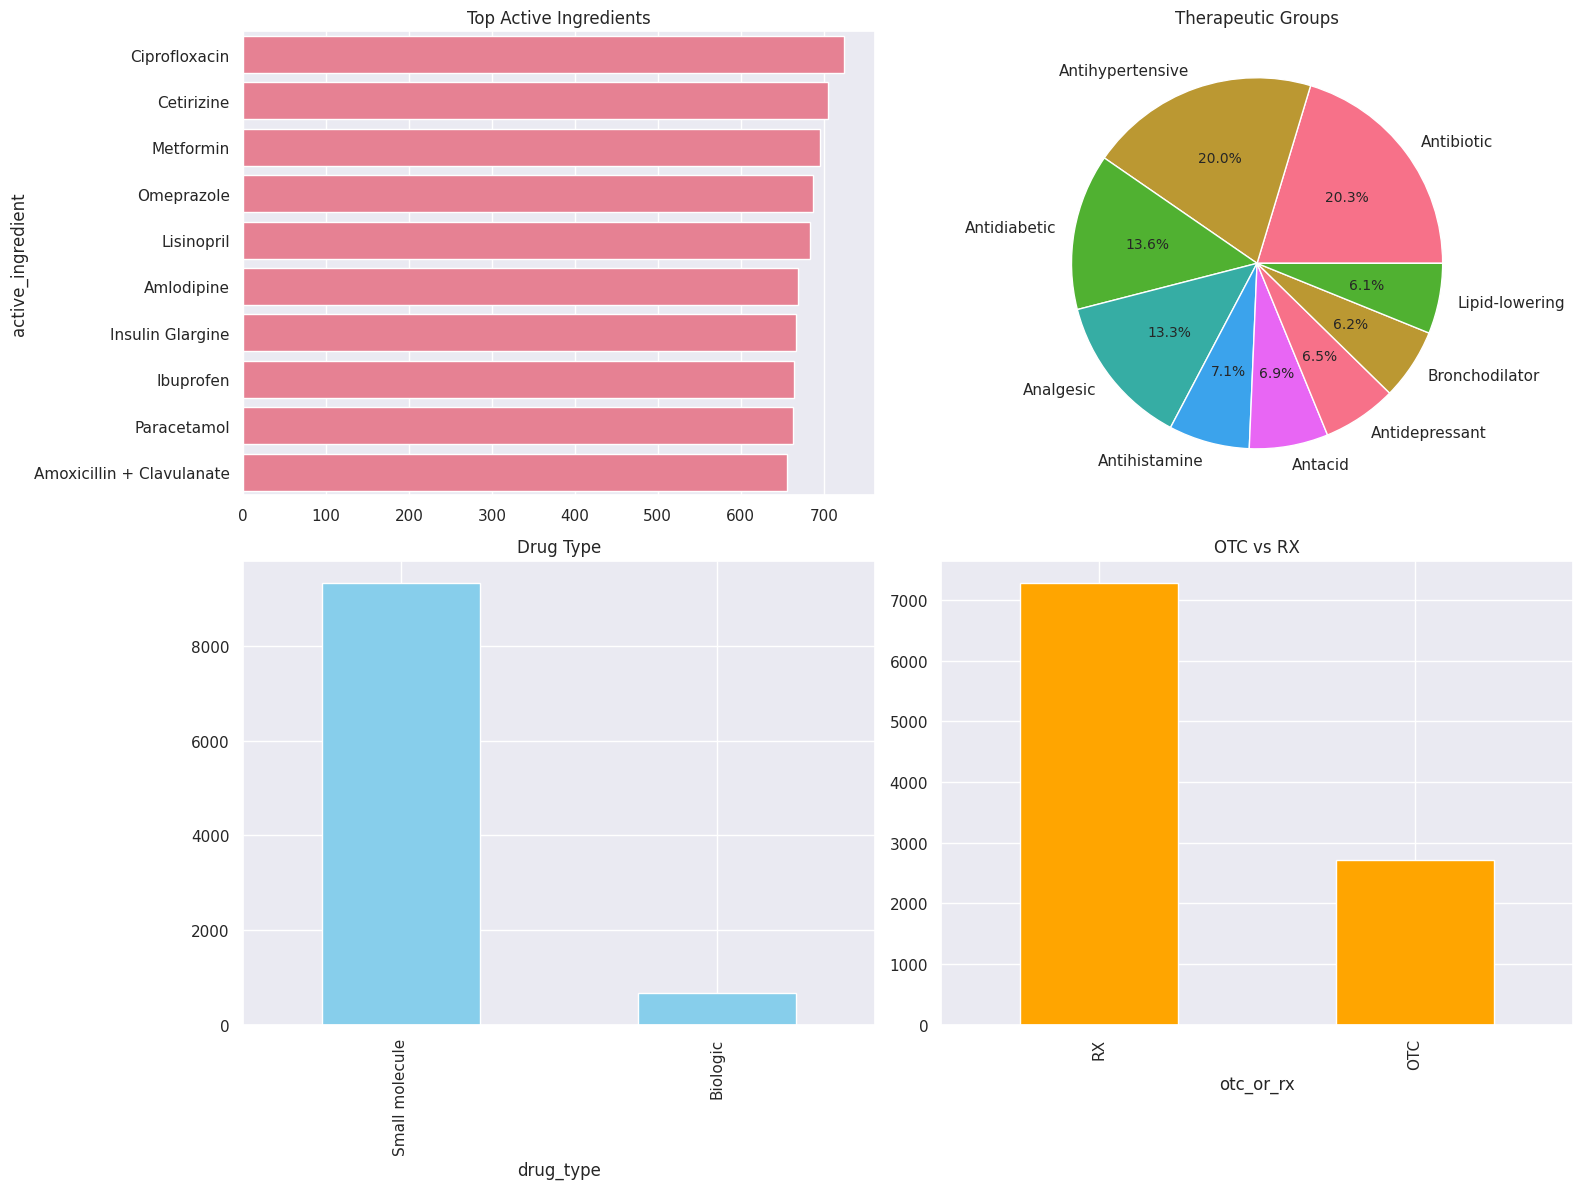

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Active ingredients
if 'active_ingredient' in df.columns:
    top = df['active_ingredient'].value_counts().head(10)
    sns.barplot(x=top.values, y=top.index, ax=axes[0,0])
    axes[0,0].set_title("Top Active Ingredients")

# Therapeutic group
if 'therapeutic_group' in df.columns:
    df['therapeutic_group'].value_counts().plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%')
    axes[0,1].set_ylabel("")
    axes[0,1].set_title("Therapeutic Groups")

# Drug type
if 'drug_type' in df.columns:
    df['drug_type'].value_counts().plot(kind='bar', ax=axes[1,0], color='skyblue')
    axes[1,0].set_title("Drug Type")

# OTC vs RX
if 'otc_or_rx' in df.columns:
    df['otc_or_rx'].value_counts().plot(kind='bar', ax=axes[1,1], color='orange')
    axes[1,1].set_title("OTC vs RX")

plt.tight_layout()
plt.show()

## Safety / Risk Analysis

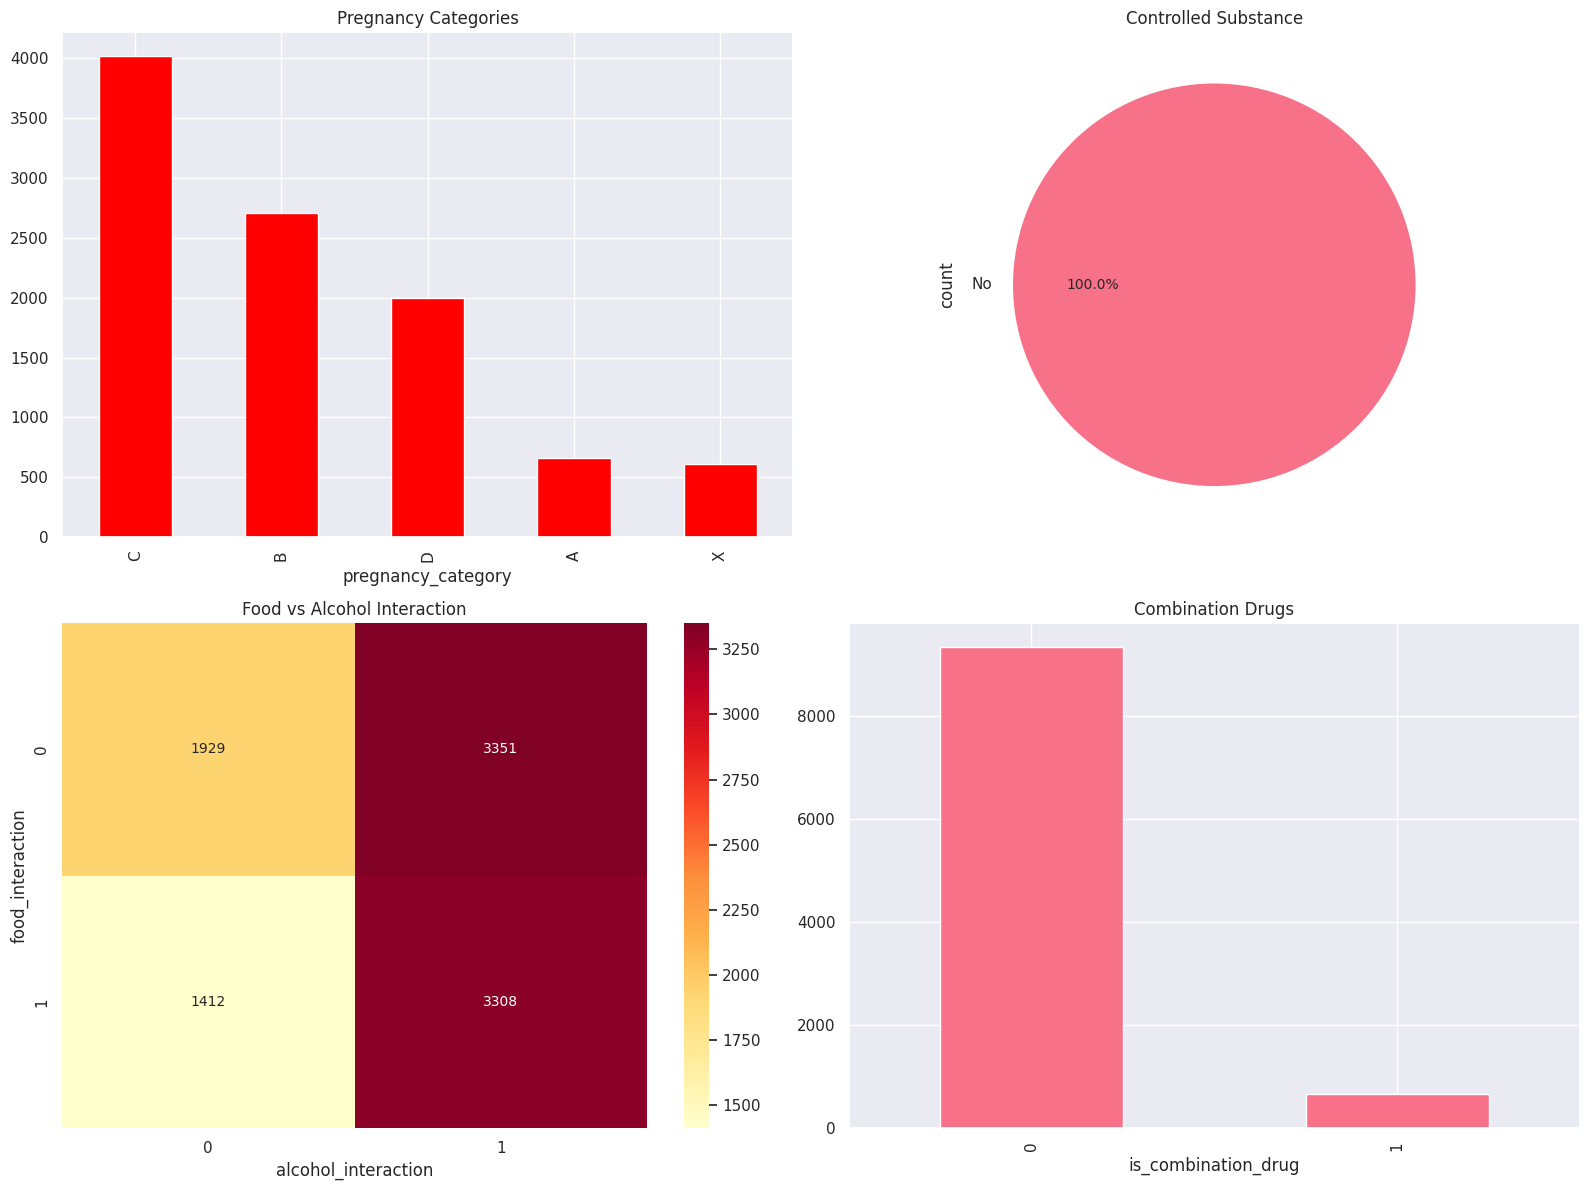

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

if 'pregnancy_category' in df.columns:
    df['pregnancy_category'].value_counts().plot(kind='bar', ax=axes[0,0], color='red')
    axes[0,0].set_title("Pregnancy Categories")

if 'controlled_substance' in df.columns:
    df['controlled_substance'].value_counts().plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%')
    axes[0,1].set_title("Controlled Substance")

if 'food_interaction' in df.columns and 'alcohol_interaction' in df.columns:
    sns.heatmap(pd.crosstab(df['food_interaction'], df['alcohol_interaction']),
                ax=axes[1,0], annot=True, fmt='d', cmap='YlOrRd')
    axes[1,0].set_title("Food vs Alcohol Interaction")

if 'is_combination_drug' in df.columns:
    df['is_combination_drug'].value_counts().plot(kind='bar', ax=axes[1,1])
    axes[1,1].set_title("Combination Drugs")

plt.tight_layout()
plt.show()

## Numeric Analysis

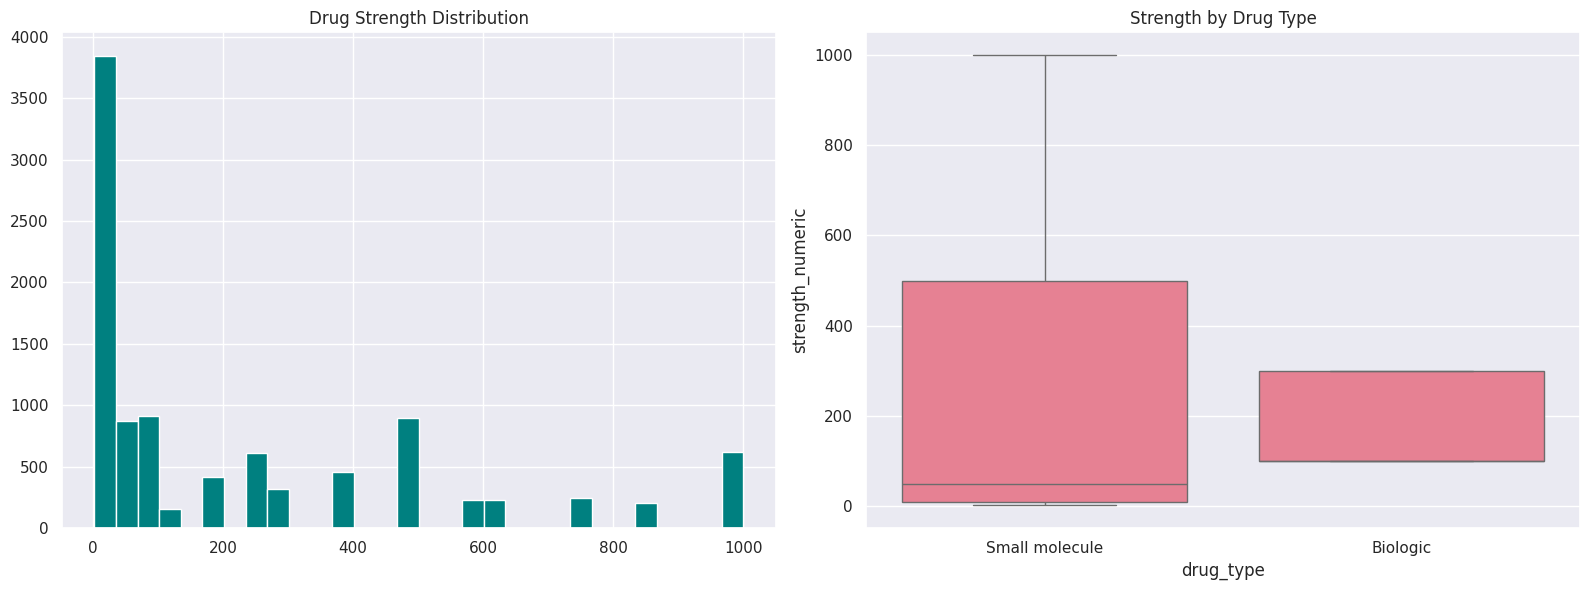

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if 'strength' in df.columns:
    df['strength_numeric'] = df['strength'].str.extract(r'(\d+)').astype(float)
    df['strength_numeric'].hist(ax=axes[0], bins=30, color='teal')
    axes[0].set_title("Drug Strength Distribution")

if 'strength_numeric' in df.columns and 'drug_type' in df.columns:
    sns.boxplot(x='drug_type', y='strength_numeric', data=df, ax=axes[1])
    axes[1].set_title("Strength by Drug Type")

plt.tight_layout()
plt.show()

#  FEATURE ENGINEERING

In [16]:

df_engineered = df.copy()

# Extract numeric strength
if 'strength' in df_engineered.columns:
    df_engineered['strength_value'] = df_engineered['strength'].str.extract(r'(\d+)').astype(float)
    df_engineered['strength_value'] = df_engineered['strength_value'].fillna(df_engineered['strength_value'].median())

# Drug frequency
if 'active_ingredient' in df_engineered.columns:
    freq = df_engineered['active_ingredient'].value_counts()
    df_engineered['drug_frequency'] = df_engineered['active_ingredient'].map(freq).fillna(0)

# Manufacturer strength
if 'manufacturer' in df_engineered.columns:
    manu_freq = df_engineered['manufacturer'].value_counts()
    df_engineered['manufacturer_strength'] = df_engineered['manufacturer'].map(manu_freq).fillna(0)


# Option A: Use OR instead of AND 
df_engineered['is_high_risk'] = (
    (df_engineered['pregnancy_category'].isin(['D', 'X'])) |
    (df_engineered['num_ingredients'] > 1) |
    (df_engineered['dosage_form'].isin(['Injection']))
).astype(int)

# Check distribution
print(f" Target distribution (OR condition):")
print(df_engineered['is_high_risk'].value_counts(normalize=True))

# If still imbalanced, try Option B (weighted scoring)
if df_engineered['is_high_risk'].sum() < len(df_engineered) * 0.05:
    print("\n Target too rare! Using weighted scoring instead...")
    
    # Option B: Weighted score (more nuanced)
    risk_score = (
        (df_engineered['pregnancy_category'].isin(['D', 'X'])).astype(int) * 3 +
        (df_engineered['num_ingredients'] > 1).astype(int) * 1 +
        (df_engineered['dosage_form'].isin(['Injection'])).astype(int) * 2
    )
    # Top 30% are high risk
    threshold = risk_score.quantile(0.7)
    df_engineered['is_high_risk'] = (risk_score >= threshold).astype(int)
    
    print(f" Target distribution (weighted scoring):")
    print(df_engineered['is_high_risk'].value_counts(normalize=True))

# Option C: If still all False, create synthetic realistic target
if df_engineered['is_high_risk'].sum() == 0:
    print("\n WARNING: No high-risk drugs found! Creating realistic synthetic target...")
    
    # Create realistic risk factors
    risk_factors = []
    
    if 'pregnancy_category' in df_engineered.columns:
        risk_factors.append(df_engineered['pregnancy_category'].isin(['C', 'D', 'X']).astype(int))
    
    if 'controlled_substance' in df_engineered.columns:
        risk_factors.append((df_engineered['controlled_substance'] == 'Yes').astype(int))
    
    if 'alcohol_interaction' in df_engineered.columns:
        risk_factors.append(df_engineered['alcohol_interaction'].astype(int))
    
    if 'food_interaction' in df_engineered.columns:
        risk_factors.append(df_engineered['food_interaction'].astype(int))
    
    if 'is_combination_drug' in df_engineered.columns:
        risk_factors.append(df_engineered['is_combination_drug'].astype(int))
    
    if risk_factors:
        # Combine risk factors
        total_risk = sum(risk_factors)
        # Top 30% are high risk
        threshold = total_risk.quantile(0.7)
        df_engineered['is_high_risk'] = (total_risk >= threshold).astype(int)
    else:
        # Last resort: balanced random
        df_engineered['is_high_risk'] = np.random.choice([0, 1], len(df_engineered), p=[0.7, 0.3])
    
    print(f" Target distribution (synthetic):")
    print(df_engineered['is_high_risk'].value_counts(normalize=True))


noise_idx = np.random.choice(df_engineered.index, size=int(0.05*len(df_engineered)), replace=False)
df_engineered.loc[noise_idx, 'is_high_risk'] = 1 - df_engineered.loc[noise_idx, 'is_high_risk']
print(f"\n Added 5% label noise for realistic modeling")

# Final verification
print(f"\n FINAL Target distribution:")
print(df_engineered['is_high_risk'].value_counts())
print(f"High Risk Ratio: {df_engineered['is_high_risk'].mean():.2%}")


 Target distribution (OR condition):
is_high_risk
0    0.558
1    0.442
Name: proportion, dtype: float64

 Added 5% label noise for realistic modeling

 FINAL Target distribution:
is_high_risk
0    5520
1    4480
Name: count, dtype: int64
High Risk Ratio: 44.80%


## REMOVING ALL LEAKAGE FEATURE

In [17]:


# Remove leakage features
leakage_cols = [
    'food_interaction',
    'alcohol_interaction', 
    'interaction_weighted',
    'route',
    'route_complexity'
]

drop_cols = ['id', 'controlled_substance']

# Features used in target creation (remove these too!)
target_used_cols = ['pregnancy_category', 'num_ingredients', 'dosage_form']

# Combine all columns to exclude
exclude_cols = ['is_high_risk'] + leakage_cols + drop_cols + target_used_cols

# Simple correct feature selection
feature_cols = [col for col in df_engineered.columns if col not in exclude_cols]

print(f" Removed {len(leakage_cols)} leakage features: {leakage_cols}")
print(f" Removed {len(target_used_cols)} target-derived features: {target_used_cols}")
print(f" Removed {len(drop_cols)} useless features: {drop_cols}")
print(f" Final feature count: {len(feature_cols)}")

X = df_engineered[feature_cols]
y = df_engineered['is_high_risk']

# Check if y has both classes
print(f"\n Target classes in y: {y.unique()}")
print(f"Class distribution:\n{y.value_counts()}")

# If y still has only one class, force balance
if len(y.unique()) < 2:
    print("\n CRITICAL: Target has only one class! Forcing balance...")
    y = pd.Series(np.random.choice([0, 1], len(df_engineered), p=[0.7, 0.3]))
    print(f"New class distribution:\n{y.value_counts()}")

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n Final categorical features ({len(categorical_cols)}): {categorical_cols[:5]}...")
print(f" Final numerical features ({len(numerical_cols)}): {numerical_cols[:5]}...")


 Removed 5 leakage features: ['food_interaction', 'alcohol_interaction', 'interaction_weighted', 'route', 'route_complexity']
 Removed 3 target-derived features: ['pregnancy_category', 'num_ingredients', 'dosage_form']
 Removed 2 useless features: ['id', 'controlled_substance']
 Final feature count: 16

 Target classes in y: [1 0]
Class distribution:
is_high_risk
0    5520
1    4480
Name: count, dtype: int64

 Final categorical features (11): ['active_ingredient', 'brand_name', 'manufacturer', 'therapeutic_group', 'pharmacological_class']...
 Final numerical features (5): ['is_combination_drug', 'strength_numeric', 'strength_value', 'drug_frequency', 'manufacturer_strength']...


# PREPROCESSING PIPELINE

In [18]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])


# MODEL TRAINING

In [19]:

models = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, 
                              random_state=42, eval_metric='logloss', use_label_encoder=False),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                                random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(n_estimators=300, depth=5, learning_rate=0.1,
                                    random_state=42, verbose=0),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, 
                                            random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                    learning_rate=0.1, random_state=42)
}

results = {}
best_model = None
best_f1 = 0

for name, model in models.items():
    
    print(f"Training {name}...")
    
    try:
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('feature_select', SelectKBest(mutual_info_classif, k=min(30, len(feature_cols)))),
            ('classifier', model)
        ])
        
        # Stratified K-Fold Cross Validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        results[name] = {
            'pipeline': pipeline,
            'cv_f1_mean': cv_scores.mean(),
            'cv_f1_std': cv_scores.std(),
            'test_accuracy': accuracy,
            'test_f1': f1,
            'test_precision': precision,
            'test_recall': recall,
            'test_auc': auc,
            'predictions': y_pred
        }
        
        print(f"CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        print(f"Test Acc: {accuracy:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
        print(classification_report(y_test, y_pred))
        
        if f1 > best_f1:
            best_f1 = f1
            best_model = name
            best_pipeline = pipeline
            
    except Exception as e:
        print(f"Error: {e}")

if best_model:
   
    print(f" BEST MODEL: {best_model} with F1: {best_f1:.4f}")
    print(f" REALISTIC SCORES: Acc={results[best_model]['test_accuracy']:.3f}, F1={best_f1:.3f}")
   
else:
    print("\n No models trained successfully - check target variable")


Training XGBoost...
CV F1: 0.8896 (+/- 0.0133)
Test Acc: 0.8965 | F1: 0.8763 | AUC: 0.9255
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1104
           1       0.94      0.82      0.88       896

    accuracy                           0.90      2000
   macro avg       0.91      0.89      0.89      2000
weighted avg       0.90      0.90      0.90      2000

Training LightGBM...
CV F1: 0.8895 (+/- 0.0131)
Test Acc: 0.8965 | F1: 0.8763 | AUC: 0.9256
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1104
           1       0.94      0.82      0.88       896

    accuracy                           0.90      2000
   macro avg       0.91      0.89      0.89      2000
weighted avg       0.90      0.90      0.90      2000

Training CatBoost...
CV F1: 0.8896 (+/- 0.0133)
Test Acc: 0.8965 | F1: 0.8763 | AUC: 0.9253
              precision    recall  f1-score   support

           0    

## CONFUSION MATRIX

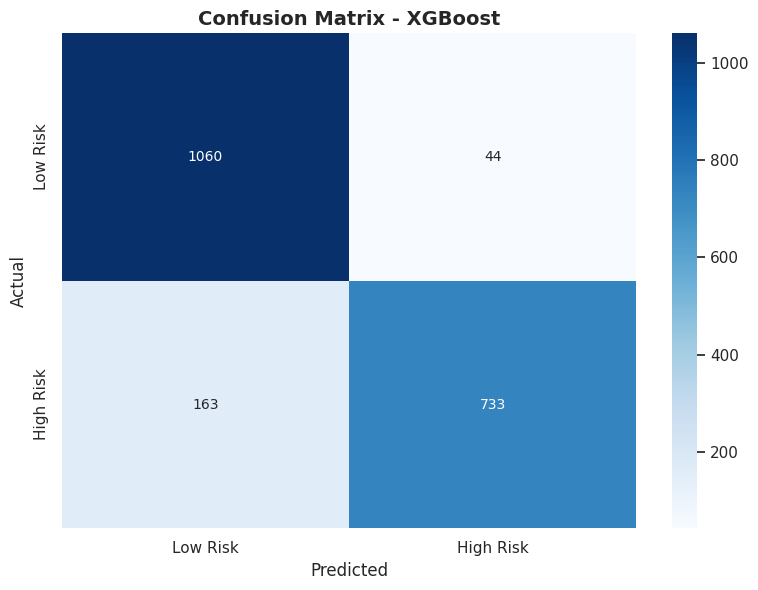

In [20]:
if best_model in results:
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, results[best_model]['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    plt.title(f'Confusion Matrix - {best_model}', fontsize=14, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()